In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
    
This code was built using `NumPy: 2.2.5`, `SciPy: 1.15.1`, `SymPy: 1.13.3`.
</div>

In this notebook we will learn how to apply the deflation technique from [[1]](https://arxiv.org/pdf/2407.06834).

[1] Andrés Miniguano-Trujillo, John William Pearson, Benjamin D Goddard (2025). **Efficient nonlocal linear image denoising: Bilevel optimization with Nonequispaced Fast Fourier Transform and matrix-free preconditioning**. Accepted at SIAM journal on Imaging Sciences. arXiv:2407.06834.

In [1]:
# Libraries
import numpy as np
import scipy.sparse as sp

In [2]:
np.set_printoptions(linewidth=180, precision = 2)

# Change of basis

<div class="alert alert-block alert-success">
Consider the hermitian matrix $A \in \mathbb{H}_n(\mathbb{F})$ with an eigenpair $(\lambda,\mathbf{v})$. We can build a deflation $U \in \mathcal{M}_n(\mathbb{F})$ based on $\mathbf{v}$ such that the matrix $\mathsf{A}_{U} = U^\top A Q$ has a block-structure that isolates $\lambda$. In what follows, we will explore how to build $U = U(\mathbf{v})$, its transpose, their operator forms, and test them against a set of exact and numerical examples. Notice that $U$ is an unitary matrix.
</div>

## The $v_1 \neq 0$ case

Let us assume that $v_1 \neq 0$ and that $v_1 \in \mathbb{R}$. In the case that $v_1 \in \mathbb{C}$, we can just multiply $\mathbf{v}$ by $\overline{\mathbf{v}}$ and carry on with the next steps. The explicit form of $U$ involves the calculation of the two vectors
\begin{align*}
    \mathbf{a}_\mathbf{v} = \Big[ 0, \big( \| \mathbf{v}_{1:i-1} \| \| \mathbf{v}_{1:i}  \|^{-1}  \big)_{ i \in [2:n] } \Big]
    \qquad\text{and}\qquad 
    \mathbf{b}_{ \mathbf{v} } := \Big[ \|\mathbf{v}\|^{-1},  \overline{ \mathbf{v} }_{2:n} \circ \big( \| \mathbf{v}_{1:i-1} \| \| \mathbf{v}_{1:i} \| \big)^{ \circ - 1 }_{ i \in [2:n] } \Big]
\end{align*}
We then obtain that
\begin{align}
    U(\mathbf{v}) = \operatorname{diag}(\mathbf{v}) 
    \begin{bmatrix} 
        \mathbb{1}_n & \operatorname{Triu}_0( \mathbb{1}_{n,n-1} ) 
    \end{bmatrix}
    \operatorname{diag}(  \mathbf{b}_{ \mathbf{v} }  ) - \operatorname{diag}(\mathbf{a}_{ \mathbf{v} } )
\end{align}

Let us implement this for any vector $\mathbf{v}$:

In [3]:
rng = np.random.default_rng(seed=2025)

In [4]:
n = 8
# Generate a random eigenvector of size n
𝐯 = rng.uniform(-1,0,n) + 1.j * np.random.uniform(-1, 1, n)
# Correct first entry
𝐯   *= 𝐯[0].conj()
𝐯[0] = 𝐯[0].real
print(𝐯)

[ 0.03+0.j    0.11-0.11j  0.12-0.03j  0.02-0.03j -0.11-0.01j  0.05-0.17j -0.06-0.13j  0.15-0.01j]


In [5]:
def U_mat(v):
    n = v.size
    # Core upper triangle
    U = np.zeros([n,n]);    U[:-1, 1:] = np.triu(np.ones([n-1,n-1]),0);    U[:,0] = 1.0
    # Compute weights
    norms = np.cumsum(v * v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:].conjugate() / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Include weights in dense core
    U = (v[::,np.newaxis] * U * b)
    # Correct diagonal
    np.fill_diagonal(U, U.diagonal() - a)
    
    # Optional: Convert to sparse
    U = sp.csr_array(U)
    
    return U
U = U_mat(𝐯)
U.toarray()

array([[ 0.1 +0.j  ,  0.69+0.69j,  0.12+0.03j,  0.02+0.03j, -0.08+0.01j,  0.03+0.09j, -0.02+0.05j,  0.04+0.j  ],
       [ 0.31-0.31j, -0.21+0.j  ,  0.5 -0.3j ,  0.13+0.03j, -0.24+0.28j,  0.37+0.19j,  0.08+0.22j,  0.15-0.13j],
       [ 0.32-0.08j,  0.  +0.j  , -0.8 +0.j  ,  0.07+0.07j, -0.27+0.09j,  0.16+0.27j, -0.04+0.17j,  0.15-0.03j],
       [ 0.05-0.08j,  0.  +0.j  ,  0.  +0.j  , -0.99+0.j  , -0.04+0.07j,  0.09+0.02j,  0.03+0.04j,  0.03-0.04j],
       [-0.31-0.02j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.88+0.j  , -0.07-0.28j,  0.08-0.14j, -0.14-0.02j],
       [ 0.15-0.47j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.79+0.j  ,  0.2 +0.18j,  0.08-0.21j],
       [-0.17-0.36j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.9 +0.j  , -0.07-0.17j],
       [ 0.42-0.03j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.91+0.j  ]])

In [6]:
np.allclose(U.T.conj().dot(U).toarray(), np.eye(n)), np.allclose(U.dot(U.T.conj()).toarray(), np.eye(n))

(True, True)

A particular property from construction is that $U^\dagger \mathbf{v} = e_1$:

In [7]:
np.allclose(U.T.conj().dot( 𝐯/np.vdot(𝐯,𝐯)**0.5 ), sp.eye(n,1).toarray().ravel() )

True

Even though the sparsity of $U$ is at least $\frac{ (n-1)(n-2) }{2n^2} \lesssim 0.5$, the density of this matrix makes it prohibitive to store it in memory. As an alternative, we can use the matrix-free operator form of $U$:
\begin{align*}
    U \mathbf{x} &= \mathbf{v} \circ \mathsf{SCS}_{\uparrow} ( \mathbf{b}_{ \mathbf{v} } \circ \mathbf{x} ) - \mathbf{a}_{ \mathbf{v} } \circ \mathbf{x},
    \\
    U^\dagger \mathbf{x} &= \overline{\mathbf{b}}_{ \mathbf{v} } \circ \mathsf{SCS}_{\downarrow} ( \overline{\mathbf{v}} \circ \mathbf{x} ) - \mathbf{a}_{ \mathbf{v} } \circ \mathbf{x},
\end{align*}

In [8]:
def U_for(x, v):
    # Build a_v and b_v
    norms = np.cumsum(v * v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:].conjugate() / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Dense core: SCS↑
    w = b * x
    c = (w.sum() - np.cumsum(w));    c[-1] = 0.0;    c += w[0]
    # Weight vector
    c *= v
    # Affine translation
    c -= a * x
    
    return c

def U_adj(x, v):
    # Build a_v and b_v
    norms = np.cumsum(v * v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:] / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Dense core: SCS↓
    w = v.conj() * x
    c = np.roll( np.cumsum(w),1)
    # Weight vector
    c *= b
    # Affine translation
    c -= a * x
    
    return c

In [9]:
𝐱 = rng.uniform(0,2,n) + 1.j * np.random.uniform(-2, 2, n)

Let's verify the application:

In [10]:
np.allclose(U_adj(U_for(𝐱,𝐯), 𝐯), 𝐱), np.allclose(U_for(U_adj(𝐱,𝐯),𝐯), 𝐱)

(True, True)

In [11]:
np.allclose(U.dot(𝐱), U_for(𝐱,𝐯)), np.allclose(U.conj().T.dot(𝐱), U_adj(𝐱,𝐯))

(True, True)

## The case $v_1=0$

Let $\imath \in [2:n]$ be the first index where $v_i \neq 0$.
There are two paths available for this case: 

**(1)** Apply a permutation $(1,\imath) \in \operatorname{S}_n$, represented by the matrix $P_{(1,\imath)}$, to $A$ and define $B = P^\top A P$. Defining $\mathbf{v} := P^\top \mathbf{u}$, we obtain that 
\begin{align*}
    B\mathbf{u} = P^\top A P P^\top \mathbf{v} = P^\top A \mathbf{v} = P^\top \lambda \mathbf{v} = \lambda P^\top \mathbf{v}.
\end{align*}
As a result, $\mathbf{v}$ is an eigenvector of $B$ with a nonzero first entry. We can then determine $U(\mathbf{v})$, and 
\begin{align*}
    P\big[U(\mathbf{v})\big]^\dagger B \,\, U(\mathbf{v}) P^\top = P\big[U(\mathbf{v})\big]^\dagger P^\top A P \, U(\mathbf{v}) P^\top 
    = \big[P U(\mathbf{v}) P^\top\big]^\dagger A \big[P U(\mathbf{v}) P^\top\big]
\end{align*}
has a block structure with a singled-out $(\imath,\imath)$ entry. Moreover, notice that $P^2 = \mathsf{I}_n$, so we do not need to define a transpose. This yields the reduced formula
\begin{align*}
    P\big[U(\mathbf{v})\big]^\top B \,\, U(\mathbf{v}) P^\top = \big[P U(\mathbf{v}) P\big]^\dagger A \big[P U(\mathbf{v}) P\big],
\end{align*}
as a result, the resulting matrix will always be Hermitian.

In [12]:
def Permutation(v, i=0):
    n = v.size
    P = sp.eye(n, format = 'dok')
    P[[0, i]] = P[[i, 0]]    # Swap rows 0 and i
    return P.tocsr()
def Pv_op(u, i=0):
    v = u.copy()
    v[0], v[i] = v[i], v[0]
    return v

In [13]:
P = Permutation(𝐯,1)
np.allclose(P.T.dot(P).toarray(), np.eye(n))

True

In [14]:
np.allclose(Permutation(v, 3).dot(𝐱), Pv_op(𝐱,3)), np.allclose( Pv_op(Pv_op(𝐱, 3),3), 𝐱)

(True, True)

**(2)** Alternatively, we can extend the definition of $U$ as follows:
\begin{align}
U(\mathbf{v},\imath) =
\begin{bmatrix}
    \mathsf{I}_{\imath-1}
    \\
    & 
    \operatorname{diag}(\mathbf{v}_{\imath:n}) 
    \begin{bmatrix} 
        \mathbb{1}_{n-\imath+1} & \operatorname{Triu}_0( \mathbb{1}_{n-\imath+1,n-\imath} ) 
    \end{bmatrix}
    \operatorname{diag}(  \mathbf{b}_{ \mathbf{v} }  ) - \operatorname{diag}(\mathbf{a}_{ \mathbf{v} } )
\end{bmatrix}
\end{align}

These can be easily implemented by extending the functionality of our previous implementation:

In [15]:
def U_mat(x, i=0):
    # First block
    n_diag = x[:i].size
    Id = sp.eye(n_diag, format = 'csr', dtype = x.dtype)
    
    # Second block
    v = x[i:]            # We can just recycle the code from before by defining an auxiliary variable
    n = v.size
    # Core upper triangle
    U = np.zeros([n,n]);    U[:-1, 1:] = np.triu(np.ones([n-1,n-1]),0);    U[:,0] = 1.0
    # Compute weights
    norms = np.cumsum(v*v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:].conjugate() / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Include weights in dense core
    U = (v[::,np.newaxis] * U * b)
    # Correct diagonal
    np.fill_diagonal(U, U.diagonal() - a)
    
    # Optional: Convert to sparse
    U = sp.csr_array(U)
    
    return sp.block_diag((Id, U), format = 'csr')

In [16]:
# Create vector
𝐯 = Pv_op(𝐯, 3);    𝐯[:3] = 0.0;    𝐯

array([ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.03+0.j  , -0.11-0.01j,  0.05-0.17j, -0.06-0.13j,  0.15-0.01j])

In [17]:
U = U_mat(𝐯,3)
U.toarray()

array([[ 1.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  1.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  1.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.12+0.j  , -0.95+0.07j,  0.08+0.24j, -0.04+0.08j,  0.07+0.j  ],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.37-0.03j, -0.3 +0.j  , -0.19-0.78j,  0.14-0.25j, -0.22-0.03j],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.18-0.57j,  0.  +0.j  , -0.55+0.j  ,  0.34+0.32j,  0.13-0.33j],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.21-0.43j,  0.  +0.j  ,  0.  +0.j  , -0.83+0.j  , -0.1 -0.26j],
       [ 0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  ,  0.5 -0.04j,  0.  +0.j  ,  0.  +0.j  ,  0.  +0.j  , -0.86+0.j  ]])

Again the inverse is exact:

In [18]:
np.allclose(U.dot(U.T.conj()).toarray(), np.eye(n, dtype='complex')), np.allclose(U.T.conj().dot(U).toarray(), np.eye(n, dtype='complex'))

(True, True)

Similarly, the matrix-free version of the operator can be quickly determined:
\begin{align*}
    U \mathbf{x} &= 
    \begin{bmatrix}
        \mathbf{x}_{1:\imath-1}
        \\
        \mathbf{v}_{\imath:n} \circ \mathsf{SCS}_{\uparrow} ( \mathbf{b}_{ \mathbf{v} } \circ \mathbf{x}_{\imath:n} ) - \mathbf{a}_{ \mathbf{v} } \circ \mathbf{x}_{\imath:n},
    \end{bmatrix}
    \\
    U^\dagger \mathbf{x} &= 
    \begin{bmatrix}
        \mathbf{x}_{1:\imath-1}
        \\
        \overline{\mathbf{b}}_{ \mathbf{v} } \circ \mathsf{SCS}_{\downarrow} ( \overline{\mathbf{v}}_{\imath:n} \circ \mathbf{x}_{\imath:n} ) - \mathbf{a}_{ \mathbf{v} } \circ \mathbf{x}_{\imath:n},
    \end{bmatrix}
\end{align*}
where the vectors $\mathbf{a}_{\mathbf v}$ and $\mathbf{b}_{\mathbf v}$ are defined only for $\mathbf{v}_{\imath:n}$.

In [19]:
def Uv_op(x, y, i=0):
    '''
        Computes U(y,i)x = h
        ===============================================================
        Inputs:
        x:    array (numeric) of size (n,)
        y:    array (numeric) of size (n,)
        i:    int in [0,n-1] is the index where v≠0 for the first time
        Output:
        a:    array (numeric) of size (n,)
    '''
    # First block
    h = x.copy()         # Copy x since its entries are preserved
    
    # Second block
    v = y[i:]            # We can just recycle the code from before by defining an auxiliary variable
    # Build a_v and b_v
    norms = np.cumsum(v * v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:].conjugate() / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Dense core: SCS↑
    w = b * x[i:]
    c = (w.sum() - np.cumsum(w));    c[-1] = 0.0;    c += w[0]
    # Weight vector
    c *= v
    # Affine translation
    c -= a * x[i:]
    
    # Assign entries
    h[i:] = c
    return h

def Uv_in(x, y, i=0):
    '''
        Computes the solution of U(y,i) h = x
        ===============================================================
        Inputs:
        x:    array (numeric) of size (n,)
        y:    array (numeric) of size (n,)
        i:    int in [0,n-1] is the index where v≠0 for the first time
        Output:
        h:    array (numeric) of size (n,)
    '''
     # First block
    h = x.copy()         # Copy x since its entries are preserved
    
    # Second block
    v = y[i:]            # We can just recycle the code from before by defining an auxiliary variable
    # Build a_v and b_v
    norms = np.cumsum(v * v.conjugate()).real**0.5
    b = np.r_[ norms[-1]**-1,  v[1:] / (norms[:-1] * norms[1:])]
    a = np.r_[0, norms[:-1]/(norms[1:])]
    
    # Dense core: SCS↓
    w = v.conj() * x[i:]
    c = np.roll( np.cumsum(w),1)
    # Weight vector
    c *= b
    # Affine translation
    c -= a * x[i:]
    
    # Assign entries
    h[i:] = c
    return h

In [20]:
np.allclose(Uv_op(Uv_in(𝐱, 𝐯, 3), 𝐯, 3), 𝐱), np.allclose(Uv_in(Uv_op(𝐱, 𝐯, 3), 𝐯, 3), 𝐱)

(True, True)

This is the most natural extension of the operator since it clearly preserves orthogonality of its columns against the given eigenvector and also provides a compact two-block representation. In case $\imath$ is large, the result becomes more relevant.

---

# Examples

## Exact

In [21]:
from sympy import Matrix, diag, Rational
from sympy import I, sqrt

Let us showcase the technique for an exact matrix:

In [22]:
unitary_matrix = Matrix([ [1,0,-I], [1,1,I], [-I,2*I,1]]).T * diag([1/sqrt(2),1/sqrt(3),1/sqrt(6)], unpack=True)
display(unitary_matrix * (unitary_matrix.H) - unitary_matrix.H * unitary_matrix)
A = unitary_matrix * diag([-1,2,10], unpack=True) * unitary_matrix.H
6*A

Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Matrix([
[  11,   -16, -17*I],
[ -16,    44,  16*I],
[17*I, -16*I,    11]])

By construction, we already know the eigenvalues and eigenvectors of $A$. However, we can still find them:

In [23]:
# Find eigenvectors and associated eigenvalues:
A_eigs = list(A.eigenvals().keys())
print(A_eigs)
[a.evalf() for a in A_eigs]

[10, 2, -1]


[10.0000000000000, 2.00000000000000, -1.00000000000000]

In [24]:
print('The eigenvector associated with', A.eigenvects()[0][0], 'is')
𝐯 = A.eigenvects()[0][2][0] * 2*I
𝐯

The eigenvector associated with -1 is


Matrix([
[ -2],
[  0],
[2*I]])

We can build $U(\mathbf{v})$ explicitly:

In [25]:
n = 3
U = np.zeros([n,n], dtype=int);    U[:-1, 1:] = np.triu(np.ones([n-1,n-1]),0);    U[:,0] = 1.0 
norms = np.asarray([sqrt(a) for a in np.cumsum(𝐯.conjugate().multiply_elementwise(𝐯))])
b = np.r_[1/sqrt(sum(𝐯.conjugate().multiply_elementwise(𝐯))), np.asarray((𝐯.conjugate())[1:]) / (norms[:-1] * norms[1:])]
a = np.r_[0, norms[:-1]/(norms[1:])]
U = Matrix((np.asarray(𝐯) * U * b ) - np.diag(a))
U

Matrix([
[ -sqrt(2)/2,  0, sqrt(2)*I/2],
[          0, -1,           0],
[sqrt(2)*I/2,  0,  -sqrt(2)/2]])

It's conjugation by $A$ yields a block structure:

In [26]:
3 * (U.H * A * U)

Matrix([
[-3,            0,           0],
[ 0,           22, 8*sqrt(2)*I],
[ 0, -8*sqrt(2)*I,          14]])

Moreover, this Hermitian matrix has an improved condition number since its spectrum is shrinked:

In [27]:
(U.H * A * U)[1:,1:].eigenvals()

{10: 1, 2: 1}

---

## Numeric

In [28]:
import matplotlib.pyplot as plt

Let's build two examples for $n=20$. We will obtain two eigenvectors and partially diagonalise $A$:

In [29]:
rng = np.random.default_rng(seed=2025)

In [30]:
n = 20
A = rng.normal(0.0, 10, (n,n))
A = np.tril(A) + np.tril(A, -1).T    # Guarantee all entries are normal 𝐍(0,10)
A

array([[-22.21, -16.81,   5.67,   3.51,  18.47, -10.77,  -3.9 ,  11.78,   2.58,  -3.87,   7.21,  15.14,  15.99,  12.97,   6.03,   3.48,  -0.38,  15.08,  14.73,  -1.61],
       [-16.81,  -4.  ,   4.84,  -2.59,   6.59,  18.27,   8.82,  -2.78,   3.24,   3.32,   3.03,  -5.93,  16.53,   8.31,   0.97,   1.32,  -4.4 ,  -4.8 ,   3.12,  30.34],
       [  5.67,   4.84,  10.82,   1.55,   8.9 ,  -0.03,  17.85, -17.61, -10.32,  -0.74,  10.39,  -4.76,   2.47,   1.18,   1.87,   4.27,  -8.14,  -9.69,  -3.02, -13.36],
       [  3.51,  -2.59,   1.55,  15.53, -17.33, -10.61,   4.74,   1.9 ,   5.95,   0.26,  32.32,  -8.46, -11.41,   5.77,  12.9 ,   7.7 ,  -1.94,   3.88,  11.51,  21.57],
       [ 18.47,   6.59,   8.9 , -17.33,   6.1 ,   7.16,  15.65,  -8.97, -10.49,   5.68,  -9.35,  -2.25,   1.74, -10.89,  -9.59,   7.25,   5.43,  -8.87, -17.48,   4.51],
       [-10.77,  18.27,  -0.03, -10.61,   7.16,  -2.32,   9.93, -17.57, -13.89,  15.27,  -5.07,   5.64, -14.97,  -0.46,  12.94,   9.45,   0.4 ,  10.67,  -6

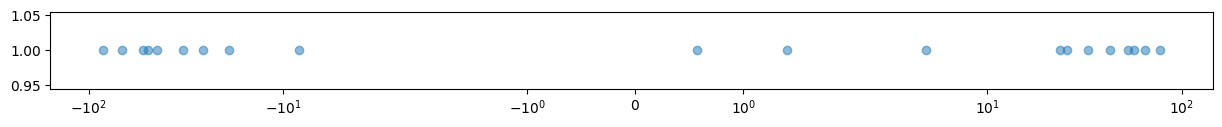

In [31]:
Λ = np.linalg.eigvalsh(A)
plt.figure(figsize=(15,1));    plt.plot( Λ, np.ones(n), 'o', alpha = 0.5 );    plt.xscale('symlog');    plt.show()

In [32]:
print('By removing the smallest eigenvalue, we can improve the condition number from {0:.2f} to {1:.2f}.'.format(abs(Λ).max()/abs(Λ).min(), abs(Λ).max()/np.sort(abs(Λ))[1]))

By removing the smallest eigenvalue, we can improve the condition number from 146.62 to 59.77.


Instead of computing all the eigenvectors, we can just use a Lanczos iteration to determine the vectors associated with the two smallest eigenvalues (in magnitude):

In [33]:
Λ_partial, 𝐕 = sp.linalg.eigsh(A, 2, sigma=0, which='LM')
Λ_partial

array([0.57, 1.41])

Let us build $U(\mathbf{v}^{(1)})$ and the conjugation $B = \big[ U(\mathbf{v}^{(1)}) \big]^\top A U(\mathbf{v}^{(1)})$

In [34]:
𝐯 = 𝐕.T[0]
𝐯

array([ 0.3 , -0.02, -0.18,  0.19,  0.36,  0.15, -0.05,  0.11, -0.1 ,  0.01,  0.19,  0.2 ,  0.02,  0.07,  0.44, -0.49,  0.18, -0.06, -0.32,  0.12])

In [35]:
U = U_mat(𝐯,0)
np.allclose(np.eye(n), U.conj().T.dot(U).toarray())

True

In [36]:
B = U.conj().T.dot(A).dot(U.toarray())
abs(B[0,0] - Λ_partial[0])    # Eigenvalue error at machine precision

np.float64(1.887379141862766e-15)

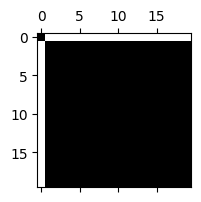

In [37]:
plt.figure(figsize=(2,2));    plt.spy(np.around(B, 10));    plt.show()

We can compute the action of $B$ in a matrix-free fashion as well to avoid storing $Q$ and its inverse: 

In [38]:
𝐮 = rng.uniform(-1,5,n)

In [39]:
a = Uv_in( A.dot( Uv_op(𝐮, 𝐯, i=0)), 𝐯, i=0)
np.allclose(a, B.dot(𝐮))

True

If we want to improve the precision of the first entry, we can even discard the output of the transformation and use the eigenvalue directly:

In [40]:
abs(Λ_partial[0] * 𝐮[0] - a[0])

np.float64(2.8310687127941492e-14)

We know that the deflation allows us to reduce the condition number of the subblock $S=B_{2:n,2:n}$:

In [41]:
print('cond(A) = {0:.2f}, cond(S) = {1:.2f}'.format(np.linalg.cond(A), np.linalg.cond(B[1:,1:])))

cond(A) = 146.62, cond(S) = 59.77


At this point, let us also conjugate by the action of the second eigenvector. We know that $A\mathbf{v}^{(2)} = \lambda^{(2)} \mathbf{v}^{(2)}$. As a result, we have that 
\begin{align*}
    \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger A\, U(\mathbf{v}^{(1)},1) \Big[ \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger \mathbf{v}^{(2)} \Big] 
    = 
    \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger A\, \mathbf{v}^{(2)}  
    =
    \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger \lambda^{(2)}   \mathbf{v}^{(2)}  
    =
    \lambda^{(2)}  \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger \mathbf{v}^{(2)}.
\end{align*}
Hence we can use the eigeninformation of $\mathbf{v}^{(1)}$ to project $\mathbf{v}^{(2)}$ into the new basis such that it remains an eigenvector. Moreover, since $\mathbf{v}^{(1)}$ has a nonzero first entry, then we know that $\mathbf{v}^{(2)}_* := \big[ U(\mathbf{v}^{(1)},1) \big]^\dagger \mathbf{v}^{(2)}$ must have a zero first entry due to spectral orthogonality.

In [42]:
𝐯_1 = 𝐕.T[0]
𝐯_2 = Uv_in(𝐕.T[1], 𝐯_1, i=0);    print(𝐯_2);    𝐯_2[0] = 0.0    # Correct floating point error

[-7.29e-17 -8.96e-02  4.51e-02 -6.23e-02  2.16e-01 -2.37e-01 -6.05e-01 -1.32e-01 -3.73e-01  1.10e-01  1.70e-01 -1.79e-01 -9.50e-02 -4.40e-02 -3.70e-01 -8.77e-02 -2.16e-01
 -2.06e-01 -3.47e-02  2.06e-01]


In [43]:
np.linalg.norm(B.dot(𝐯_2)/Λ_partial[1] - 𝐯_2)

np.float64(1.0771115136875536e-14)

Then we can build $C = \big[ U(\mathbf{v}^{(2)}_*,2) \big]^\dagger B \,\,  U(\mathbf{v}^{(2)}_*,2) = \big[ U(\mathbf{v}^{(1)},1) U(\mathbf{v}^{(2)}_*,2) \big]^\dagger A \, \, U(\mathbf{v}^{(1)},1) U(\mathbf{v}^{(2)}_*,2)$:

In [44]:
U_2 = U_mat(𝐯_2, 2 -1)

[1.89e-15 1.78e-15]


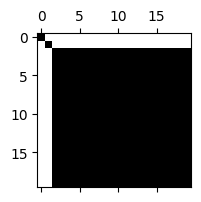

In [45]:
C = U_2.conj().T.dot(B).dot(U_2.toarray())
print( abs(C.diagonal()[:2] - Λ_partial) )    # Eigenvalue error at machine precision
plt.figure(figsize=(2,2));    plt.spy(np.around(C, 10));    plt.show()

Notice that $C$ **is** symmetric. Moreover, we have the following effect on the condition number:

In [46]:
print('cond(A) = {0:.2f}, cond(S_1) = {1:.2f}, cond(S_2) = {2:.2f}'.format(np.linalg.cond(A), np.linalg.cond(B[1:,1:]), np.linalg.cond(C[2:,2:]) ))

cond(A) = 146.62, cond(S_1) = 59.77, cond(S_2) = 17.40


At last, we can also compute the action of $C$ without storing anything else than $A$ and its two eigenvectors:

In [47]:
𝐮 = rng.uniform(-1,5,n)

In [48]:
# Three step product:
b = Uv_op( Uv_op(𝐮, 𝐯_2, i=1), v_1, i=0)    # Change of basis
b = A.dot(b)                                # Dense operator
b = Uv_in( Uv_in(b, 𝐯_1, i=0), 𝐯_2, i=1)    # Project back to basis
b[0] = 𝐮[0] * Λ_partial[0]

# Compare
np.allclose(b, C.dot(𝐮))

True

---